# Ginkgo Test Reports Analysis

This notebook processes and visualizes Golang Ginkgo test reports from GitHub Actions.
It extracts test data from zip files and creates comparison charts across different runs.

In [7]:
import os
import json
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import glob
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [10]:
# Configuration
REPORTS_DIR = "./reports"  # Configurable reports directory
TEMP_EXTRACT_DIR = "temp_extracted"

print(f"Reports directory: {REPORTS_DIR}")
print(f"Directory exists: {os.path.exists(REPORTS_DIR)}")

Reports directory: ./reports
Directory exists: True


In [18]:
def extract_zip_files(reports_dir, temp_dir):
    """Extract all zip files in the reports directory"""
    zip_files = glob.glob(os.path.join(reports_dir, "*.zip"))
    
    # Create temp directory if it doesn't exist
    os.makedirs(temp_dir, exist_ok=True)
    
    extracted_dirs = []
    
    for zip_file in zip_files:
        zip_name = os.path.splitext(os.path.basename(zip_file))[0]
        extract_path = os.path.join(temp_dir, zip_name)
        
        # Remove existing extraction directory if it exists
        if os.path.exists(extract_path):
            import shutil
            shutil.rmtree(extract_path)
        
        print(f"Extracting {zip_file} to {extract_path}")
        
        try:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                # List contents first to debug
                print(f"Contents of {zip_file}:")
                file_list = zip_ref.namelist()
                for file_name in file_list[:10]:  # Show first 10 files
                    print(f"  {file_name}")
                if len(file_list) > 10:
                    print(f"  ... and {len(file_list) - 10} more files")
                
                # Create the extraction directory
                os.makedirs(extract_path, exist_ok=True)
                # Extract all contents
                zip_ref.extractall(extract_path)
                
            # Check for nested zip files
            nested_zips = glob.glob(os.path.join(extract_path, "**/*.zip"), recursive=True)
            if nested_zips:
                print(f"Found {len(nested_zips)} nested zip files:")
                for nested_zip in nested_zips:
                    print(f"  {nested_zip}")
                    # Extract nested zip files
                    nested_name = os.path.splitext(os.path.basename(nested_zip))[0]
                    nested_extract_path = os.path.join(os.path.dirname(nested_zip), nested_name)
                    
                    try:
                        with zipfile.ZipFile(nested_zip, 'r') as nested_ref:
                            nested_ref.extractall(nested_extract_path)
                            print(f"  Extracted nested zip to {nested_extract_path}")
                    except Exception as e:
                        print(f"  Error extracting nested zip {nested_zip}: {e}")
                
            # Verify extraction worked
            if os.path.exists(extract_path) and os.listdir(extract_path):
                extracted_dirs.append(extract_path)
                print(f"Successfully extracted to {extract_path}")
                print(f"Top-level contents: {os.listdir(extract_path)}")
                
                # Show directory structure
                print("Directory structure:")
                for root, dirs, files in os.walk(extract_path):
                    level = root.replace(extract_path, '').count(os.sep)
                    indent = ' ' * 2 * level
                    print(f"{indent}{os.path.basename(root)}/")
                    subindent = ' ' * 2 * (level + 1)
                    for file in files[:5]:  # Show first 5 files per directory
                        print(f"{subindent}{file}")
                    if len(files) > 5:
                        print(f"{subindent}... and {len(files) - 5} more files")
                    if level > 3:  # Limit depth to avoid too much output
                        break
            else:
                print(f"Warning: No files found after extraction in {extract_path}")
                
        except zipfile.BadZipFile:
            print(f"Error: {zip_file} is not a valid zip file")
        except Exception as e:
            print(f"Error extracting {zip_file}: {e}")
    
    return extracted_dirs

# Extract all zip files
extracted_dirs = extract_zip_files(REPORTS_DIR, TEMP_EXTRACT_DIR)
print(f"Extracted {len(extracted_dirs)} zip files")

Extracting ./reports/combined-test-reports(2).zip to temp_extracted/combined-test-reports(2)
Contents of ./reports/combined-test-reports(2).zip:
  combined-test-reports.zip
Found 1 nested zip files:
  temp_extracted/combined-test-reports(2)/combined-test-reports.zip
  Extracted nested zip to temp_extracted/combined-test-reports(2)/combined-test-reports
Successfully extracted to temp_extracted/combined-test-reports(2)
Top-level contents: ['combined-test-reports.zip', 'combined-test-reports']
Directory structure:
combined-test-reports(2)/
  combined-test-reports.zip
  combined-test-reports/
    combined-artifact-contents/
      integrations/
        agntcy-dir/
Extracting ./reports/combined-test-reports(3).zip to temp_extracted/combined-test-reports(3)
Contents of ./reports/combined-test-reports(3).zip:
  combined-test-reports.zip
Found 1 nested zip files:
  temp_extracted/combined-test-reports(3)/combined-test-reports.zip
  Extracted nested zip to temp_extracted/combined-test-reports(3)

In [40]:
def parse_ginkgo_report(json_file_path):
    """Parse a single Ginkgo JSON report file"""
    try:
        with open(json_file_path, 'r') as f:
            data = json.load(f)
        
        tests = []
        
        # Handle case where data is an array
        if isinstance(data, list) and len(data) > 0:
            data = data[0]  # Use the first element
        
        # Parse test specs
        if isinstance(data, dict) and 'SpecReports' in data:
            for spec in data['SpecReports']:
                # Handle ContainerHierarchyTexts safely
                container_texts = spec.get('ContainerHierarchyTexts', [])
                if container_texts is None:
                    container_texts = []
                
                test_info = {
                    'test_name': ' '.join([node.get('Text', '') if isinstance(node, dict) else str(node) for node in container_texts]),
                    'leaf_node_text': spec.get('LeafNodeText', ''),
                    'state': spec.get('State', ''),
                    'start_time': spec.get('StartTime', ''),
                    'end_time': spec.get('EndTime', ''),
                    'run_time': spec.get('RunTime', 0) / 1e9 if spec.get('RunTime') else 0,  # Convert to seconds
                    'passed': spec.get('State', '') == 'passed',
                    'failed': spec.get('State', '') == 'failed',
                    'skipped': spec.get('State', '') == 'skipped'
                }
                tests.append(test_info)
        else:
            print(f"No SpecReports found in {json_file_path}. Available keys: {list(data.keys()) if isinstance(data, dict) else 'Not a dict'}")
        
        return tests
    except Exception as e:
        print(f"Error parsing {json_file_path}: {e}")
        return []

def collect_all_test_data(extracted_dirs):
    """Collect test data from all extracted directories"""
    all_data = []
    
    for extract_dir in extracted_dirs:
        run_name = os.path.basename(extract_dir)
        integration_dir = os.path.join(extract_dir, 'combined-test-reports', 'combined-artifact-contents','integrations')

        if not os.path.exists(integration_dir):
            print(f"No integrations directory found in {extract_dir}")
            continue
        
        # Find all project directories
        for project_dir in os.listdir(integration_dir):
            project_path = os.path.join(integration_dir, project_dir)
            
            if not os.path.isdir(project_path):
                continue
            
            reports_dir = os.path.join(project_path, 'reports')
            
            if not os.path.exists(reports_dir):
                continue
            
            # Find all JSON files
            json_files = glob.glob(os.path.join(reports_dir, '*.json'))
            
            for json_file in json_files:
                file_name = os.path.splitext(os.path.basename(json_file))[0]
                tests = parse_ginkgo_report(json_file)

                for test in tests:
                    test['run_name'] = run_name
                    test['project'] = project_dir
                    test['report_file'] = file_name
                    test['full_test_name'] = f"{test['test_name']} {test['leaf_node_text']}".strip()
                    all_data.append(test)
    
    print(f"Total test records collected: {len(all_data)}")
    return pd.DataFrame(all_data)

# Collect all test data
df = collect_all_test_data(extracted_dirs)
print(f"Collected {len(df)} test records")

# Add safety checks before accessing unique values
if not df.empty and 'project' in df.columns:
    projects = df['project'].unique()
    print(f"Projects: {projects}")
else:
    print("No project data found")

if not df.empty and 'run_name' in df.columns:
    runs = df['run_name'].unique()
    print(f"Runs: {runs}")
else:
    print("No run data found")

# Show DataFrame info if empty
if df.empty:
    print("DataFrame is empty - no test data was collected")
    print("This could mean:")
    print("1. No zip files were extracted")
    print("2. Directory structure doesn't match expected pattern")
    print("3. No JSON files found in reports directories")
    print("4. JSON files don't contain SpecReports data")
else:
    print(f"DataFrame shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")

Total test records collected: 80
Collected 80 test records
Projects: ['agntcy-dir' 'agntcy-slim']
Runs: ['combined-test-reports(2)' 'combined-test-reports(3)'
 'combined-test-reports(1)']
DataFrame shape: (80, 13)
Columns: ['test_name', 'leaf_node_text', 'state', 'start_time', 'end_time', 'run_time', 'passed', 'failed', 'skipped', 'run_name', 'project', 'report_file', 'full_test_name']


In [41]:
# Display basic statistics
if not df.empty:
    print("Dataset Overview:")
    print(f"Total tests: {len(df)}")
    print(f"Unique test names: {df['full_test_name'].nunique()}")
    print(f"Projects: {list(df['project'].unique())}")
    print(f"Test runs: {list(df['run_name'].unique())}")
    print("\nTest states distribution:")
    print(df['state'].value_counts())
    print("\nSample data:")
    print(df[['project', 'report_file', 'full_test_name', 'state', 'run_time']].head())
else:
    print("No test data found!")

Dataset Overview:
Total tests: 80
Unique test names: 24
Projects: ['agntcy-dir', 'agntcy-slim']
Test runs: ['combined-test-reports(2)', 'combined-test-reports(3)', 'combined-test-reports(1)']

Test states distribution:
state
passed     65
skipped    15
Name: count, dtype: int64

Sample data:
      project        report_file  \
0  agntcy-dir  report-agntcy-dir   
1  agntcy-dir  report-agntcy-dir   
2  agntcy-dir  report-agntcy-dir   
3  agntcy-dir  report-agntcy-dir   
4  agntcy-dir  report-agntcy-dir   

                                      full_test_name   state  run_time  
0                                                     passed  0.000025  
1  Agntcy directory networking test agent push, p...  passed  4.336929  
2  Agntcy directory networking test agent push, p...  passed  0.611143  
3  Agntcy directory networking test agent push, p...  passed  0.570390  
4  Agntcy agent push tests agent push and pull sh...  passed  0.633829  


<Figure size 1200x600 with 0 Axes>

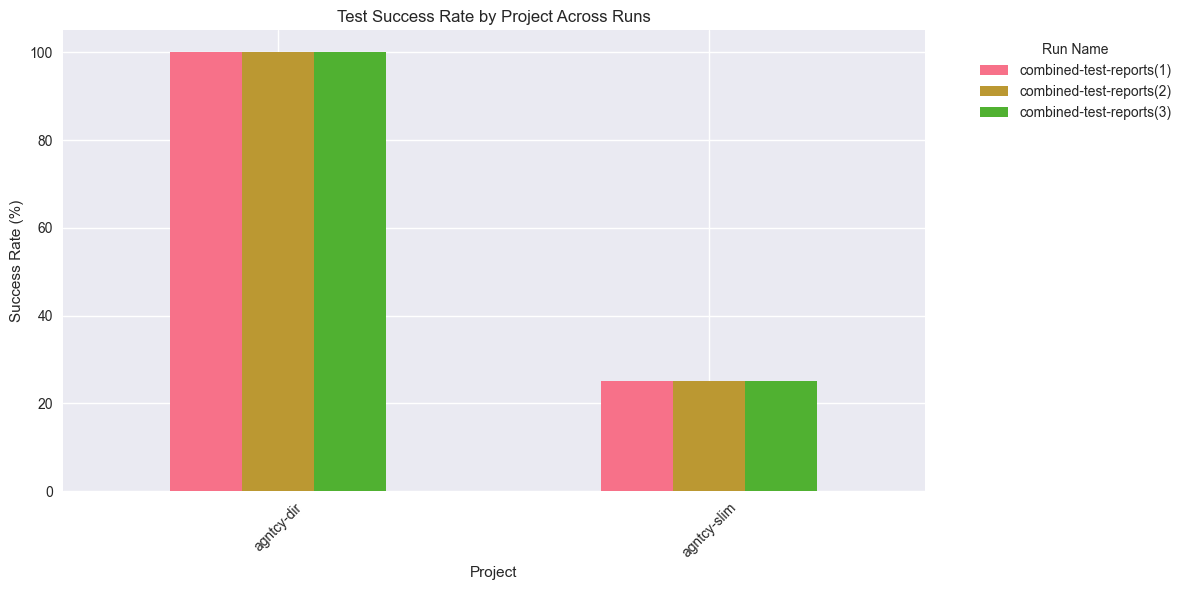

In [42]:
def plot_test_success_rate_by_project(df):
    """Plot test success rate by project across different runs"""
    if df.empty:
        return
    
    # Calculate success rates
    success_data = df.groupby(['run_name', 'project']).agg({
        'passed': 'sum',
        'failed': 'sum',
        'skipped': 'sum'
    }).reset_index()
    
    success_data['total'] = success_data['passed'] + success_data['failed'] + success_data['skipped']
    success_data['success_rate'] = success_data['passed'] / success_data['total'] * 100
    
    plt.figure(figsize=(12, 6))
    
    # Create pivot table for easier plotting
    pivot_data = success_data.pivot(index='project', columns='run_name', values='success_rate')
    
    ax = pivot_data.plot(kind='bar', figsize=(12, 6))
    plt.title('Test Success Rate by Project Across Runs')
    plt.xlabel('Project')
    plt.ylabel('Success Rate (%)')
    plt.legend(title='Run Name', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_test_success_rate_by_project(df)

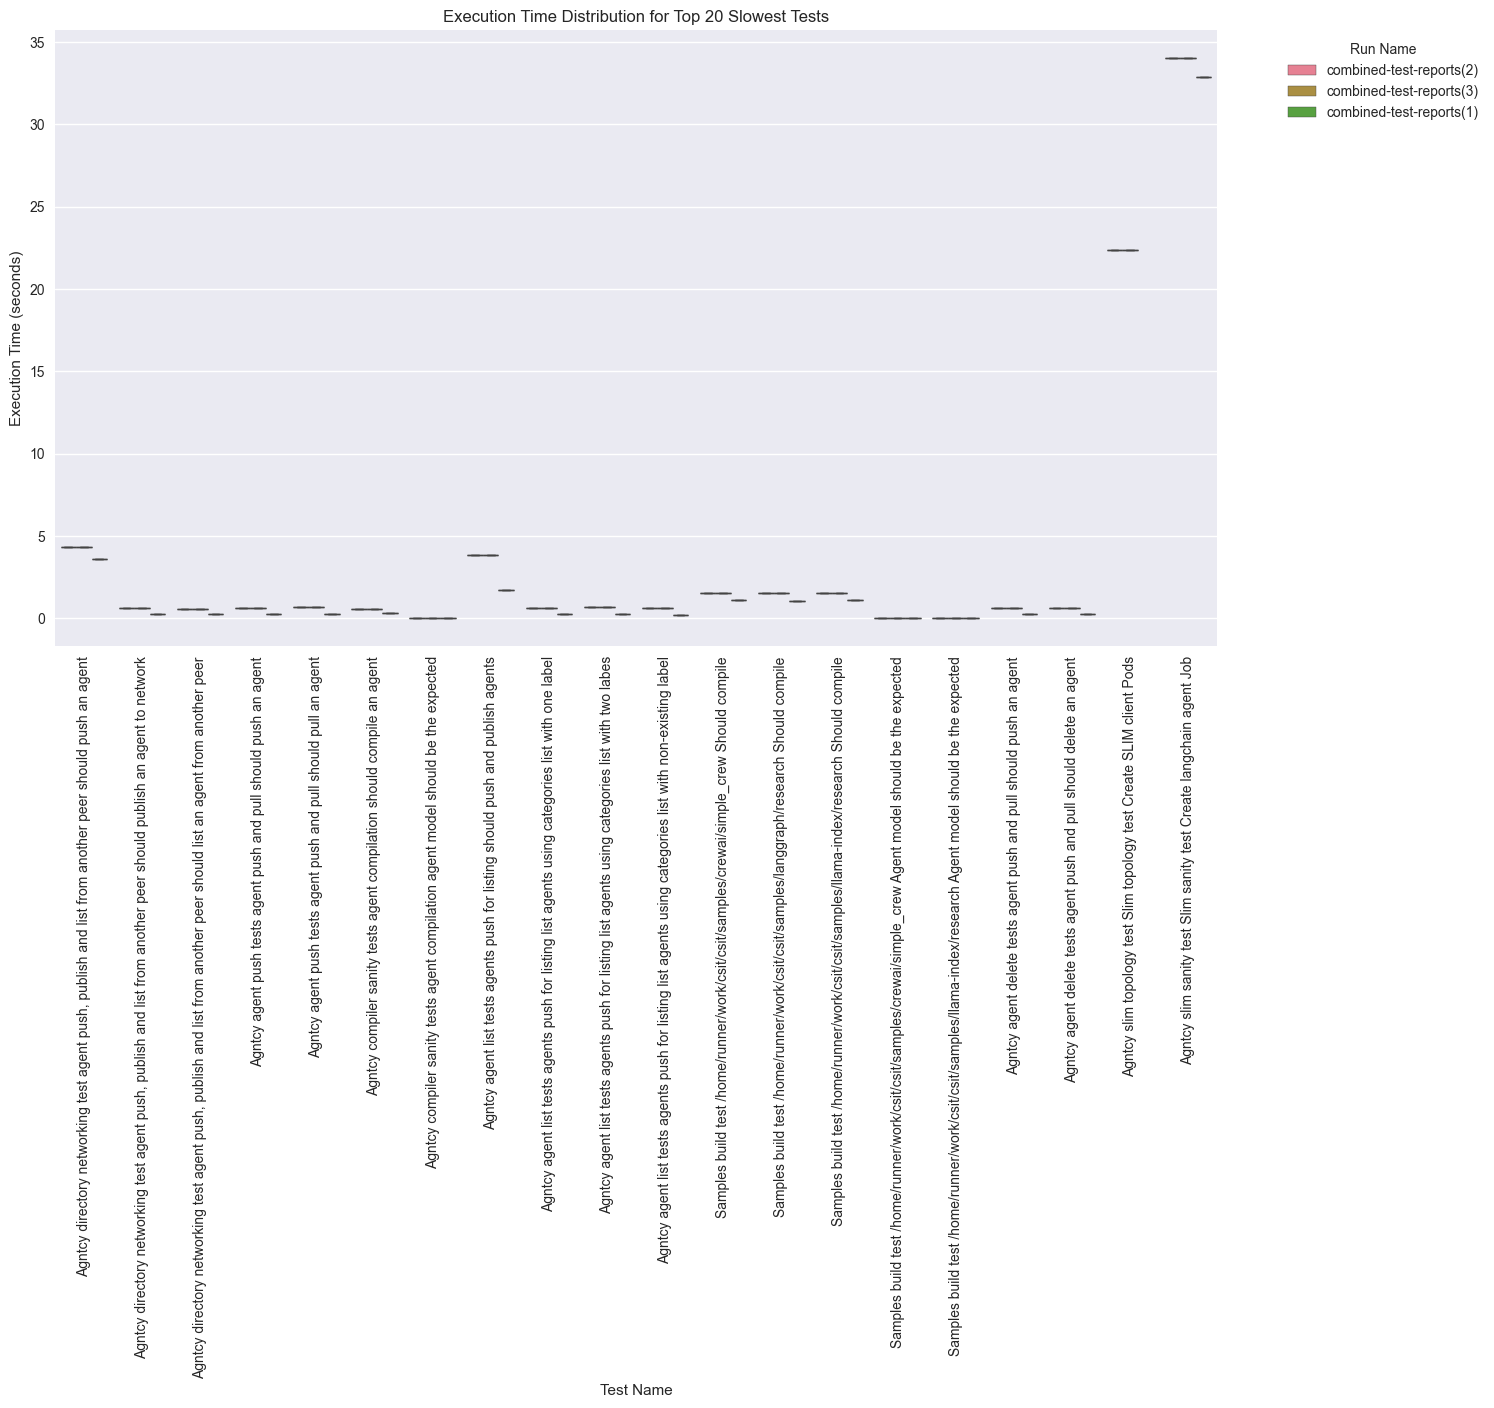

In [43]:
def plot_execution_time_comparison(df, top_n=20):
    """Plot execution time comparison for slowest tests across runs"""
    if df.empty:
        return
    
    # Filter only passed tests and get top slowest tests
    passed_tests = df[df['passed'] == True].copy()
    
    if passed_tests.empty:
        print("No passed tests found for execution time analysis")
        return
    
    # Get average execution time per test
    avg_times = passed_tests.groupby('full_test_name')['run_time'].mean().sort_values(ascending=False).head(top_n)
    top_tests = avg_times.index.tolist()
    
    # Filter data for top tests
    top_test_data = passed_tests[passed_tests['full_test_name'].isin(top_tests)]
    
    plt.figure(figsize=(15, 8))
    
    # Create box plot
    sns.boxplot(data=top_test_data, x='full_test_name', y='run_time', hue='run_name')
    plt.title(f'Execution Time Distribution for Top {top_n} Slowest Tests')
    plt.xlabel('Test Name')
    plt.ylabel('Execution Time (seconds)')
    plt.xticks(rotation=90)
    plt.legend(title='Run Name', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_execution_time_comparison(df)

<Figure size 1200x600 with 0 Axes>

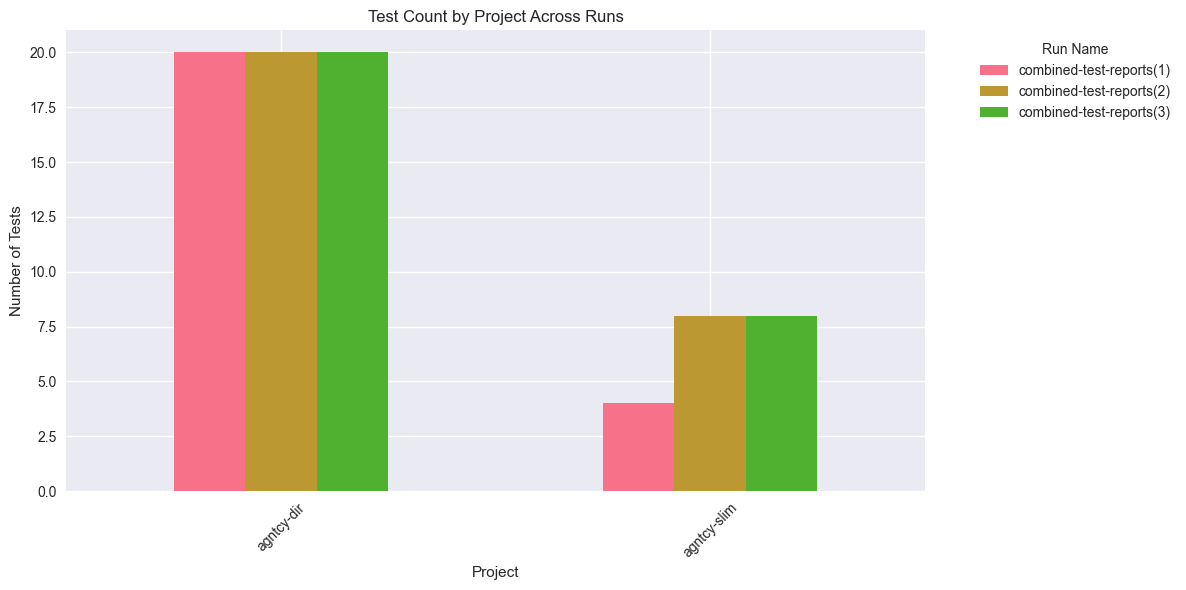

In [44]:
def plot_test_count_by_project(df):
    """Plot test count by project and run"""
    if df.empty:
        return
    
    test_counts = df.groupby(['run_name', 'project']).size().reset_index(name='test_count')
    
    plt.figure(figsize=(12, 6))
    
    pivot_counts = test_counts.pivot(index='project', columns='run_name', values='test_count')
    
    ax = pivot_counts.plot(kind='bar', figsize=(12, 6))
    plt.title('Test Count by Project Across Runs')
    plt.xlabel('Project')
    plt.ylabel('Number of Tests')
    plt.legend(title='Run Name', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_test_count_by_project(df)

In [45]:
def plot_failure_analysis(df):
    """Plot failure analysis by project"""
    if df.empty:
        return
    
    # Get failed tests by project
    failed_tests = df[df['failed'] == True]
    
    if failed_tests.empty:
        print("No failed tests found!")
        return
    
    failure_counts = failed_tests.groupby(['project', 'run_name']).size().reset_index(name='failure_count')
    
    plt.figure(figsize=(12, 6))
    
    sns.barplot(data=failure_counts, x='project', y='failure_count', hue='run_name')
    plt.title('Failed Tests by Project Across Runs')
    plt.xlabel('Project')
    plt.ylabel('Number of Failed Tests')
    plt.xticks(rotation=45)
    plt.legend(title='Run Name', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # Show most frequently failing tests
    frequent_failures = failed_tests['full_test_name'].value_counts().head(10)
    if not frequent_failures.empty:
        plt.figure(figsize=(12, 6))
        frequent_failures.plot(kind='barh')
        plt.title('Top 10 Most Frequently Failing Tests')
        plt.xlabel('Failure Count')
        plt.tight_layout()
        plt.show()

plot_failure_analysis(df)

No failed tests found!


In [46]:
def create_summary_report(df):
    """Create a summary report of test results"""
    if df.empty:
        print("No data available for summary report")
        return
    
    print("=" * 60)
    print("TEST SUMMARY REPORT")
    print("=" * 60)
    
    for run_name in df['run_name'].unique():
        run_data = df[df['run_name'] == run_name]
        
        print(f"\n📊 Run: {run_name}")
        print("-" * 40)
        
        total_tests = len(run_data)
        passed_tests = run_data['passed'].sum()
        failed_tests = run_data['failed'].sum()
        skipped_tests = run_data['skipped'].sum()
        
        success_rate = (passed_tests / total_tests * 100) if total_tests > 0 else 0
        
        print(f"Total Tests: {total_tests}")
        print(f"✅ Passed: {passed_tests} ({passed_tests/total_tests*100:.1f}%)")
        print(f"❌ Failed: {failed_tests} ({failed_tests/total_tests*100:.1f}%)")
        print(f"⏭️  Skipped: {skipped_tests} ({skipped_tests/total_tests*100:.1f}%)")
        print(f"📈 Success Rate: {success_rate:.1f}%")
        
        # Project breakdown
        print("\n📁 By Project:")
        for project in run_data['project'].unique():
            project_data = run_data[run_data['project'] == project]
            p_total = len(project_data)
            p_passed = project_data['passed'].sum()
            p_success_rate = (p_passed / p_total * 100) if p_total > 0 else 0
            print(f"  {project}: {p_passed}/{p_total} ({p_success_rate:.1f}%)")
        
        # Execution time stats
        passed_data = run_data[run_data['passed'] == True]
        if not passed_data.empty:
            avg_time = passed_data['run_time'].mean()
            max_time = passed_data['run_time'].max()
            print(f"\n⏱️  Execution Times:")
            print(f"  Average: {avg_time:.2f}s")
            print(f"  Maximum: {max_time:.2f}s")
            
            slowest_test = passed_data.loc[passed_data['run_time'].idxmax()]
            print(f"  Slowest test: {slowest_test['full_test_name'][:50]}...")

create_summary_report(df)

TEST SUMMARY REPORT

📊 Run: combined-test-reports(2)
----------------------------------------
Total Tests: 28
✅ Passed: 22 (78.6%)
❌ Failed: 0 (0.0%)
⏭️  Skipped: 6 (21.4%)
📈 Success Rate: 78.6%

📁 By Project:
  agntcy-dir: 20/20 (100.0%)
  agntcy-slim: 2/8 (25.0%)

⏱️  Execution Times:
  Average: 3.43s
  Maximum: 34.00s
  Slowest test: Agntcy slim sanity test Slim sanity test Create la...

📊 Run: combined-test-reports(3)
----------------------------------------
Total Tests: 28
✅ Passed: 22 (78.6%)
❌ Failed: 0 (0.0%)
⏭️  Skipped: 6 (21.4%)
📈 Success Rate: 78.6%

📁 By Project:
  agntcy-dir: 20/20 (100.0%)
  agntcy-slim: 2/8 (25.0%)

⏱️  Execution Times:
  Average: 3.43s
  Maximum: 34.00s
  Slowest test: Agntcy slim sanity test Slim sanity test Create la...

📊 Run: combined-test-reports(1)
----------------------------------------
Total Tests: 24
✅ Passed: 21 (87.5%)
❌ Failed: 0 (0.0%)
⏭️  Skipped: 3 (12.5%)
📈 Success Rate: 87.5%

📁 By Project:
  agntcy-dir: 20/20 (100.0%)
  agntcy-slim: 

In [47]:
# Clean up temporary files
import shutil

if os.path.exists(TEMP_EXTRACT_DIR):
    shutil.rmtree(TEMP_EXTRACT_DIR)
    print(f"Cleaned up temporary directory: {TEMP_EXTRACT_DIR}")

print("\n✅ Analysis complete!")

Cleaned up temporary directory: temp_extracted

✅ Analysis complete!
